<a href="https://colab.research.google.com/github/renanprs1/Atividade-pr-tica---SQLAlchemy/blob/main/Avalia%C3%A7%C3%A3o_G1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Leitura dos Dados**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dados/simulacao_criminalidade_brasil.csv')
print(df.shape)
print(df.head())
print(df.info())

(4440, 15)
    ano  mes        data regiao  uf       cidade      bairro  \
0  2015    1  2015-01-01  Norte  AM       Manaus      Centro   
1  2015    1  2015-01-01  Norte  PA        Belém  Zona Norte   
2  2015    1  2015-01-01  Norte  PA     Santarém   Periferia   
3  2015    1  2015-01-01  Norte  RO  Porto Velho    Zona Sul   
4  2015    1  2015-01-01  Norte  TO       Palmas    Zona Sul   

            tipo_crime periodo_dia  ocorrencias  vitimas  prisoes  \
0          Estelionato   Madrugada           42        6        5   
1                Furto       Noite           25        4        3   
2                Furto       Manhã           22        1        3   
3  Violência doméstica       Tarde           27        5        4   
4          Estelionato   Madrugada           27        6        4   

   renda_media  indice_violencia nivel_risco  
0      2391.23             72.87       Médio  
1      3126.24             85.27     Crítico  
2      3315.82             73.02        Alto  
3

**Limpeza e Preparação**

In [3]:
# Verificar nulos
print(df.isnull().sum())

# Converter data
df['data'] = pd.to_datetime(df['data'])

# Criar colunas auxiliares
df['ano_mes'] = df['data'].dt.to_period('M').astype(str)
df['trimestre'] = df['data'].dt.quarter
df['taxa_prisao'] = df['prisoes'] / df['ocorrencias'].replace(0, np.nan)
df['vitimas_por_ocorrencia'] = df['vitimas'] / df['ocorrencias'].replace(0, np.nan)

# Remover duplicatas
df = df.drop_duplicates()

ano                 0
mes                 0
data                0
regiao              0
uf                  0
cidade              0
bairro              0
tipo_crime          0
periodo_dia         0
ocorrencias         0
vitimas             0
prisoes             0
renda_media         0
indice_violencia    0
nivel_risco         0
dtype: int64


**Engenharia de Atributos**

In [4]:
# Classificar risco em ordem
ordem_risco = {'Baixo': 1, 'Médio': 2, 'Alto': 3, 'Crítico': 4}
df['risco_num'] = df['nivel_risco'].map(ordem_risco)

# Faixa de renda
df['faixa_renda'] = pd.cut(df['renda_media'],
                           bins=[0, 2000, 3000, 4000, 10000],
                           labels=['Baixa', 'Média-Baixa', 'Média-Alta', 'Alta'])

**Análise Exploratória**

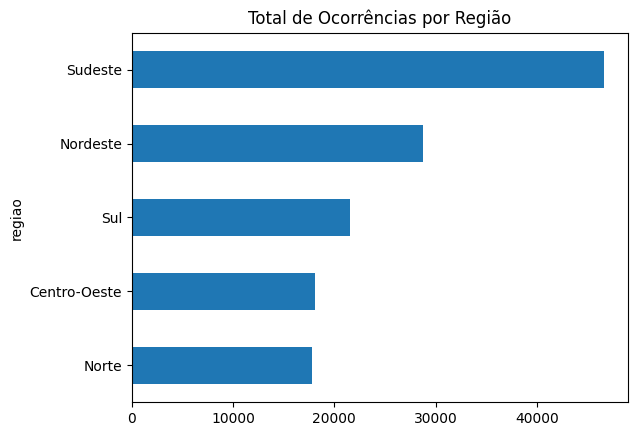

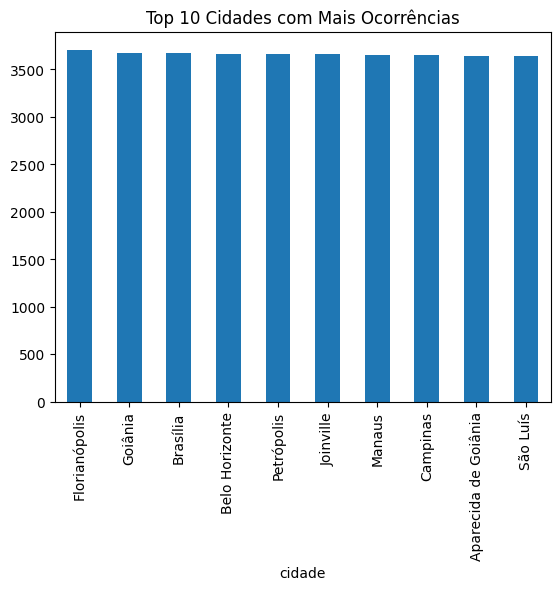

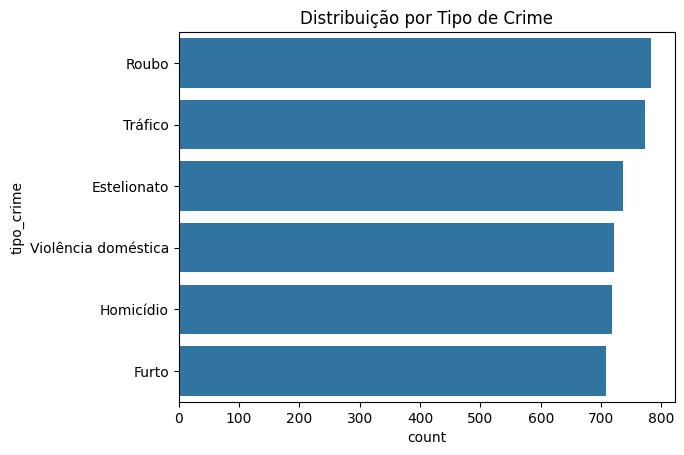

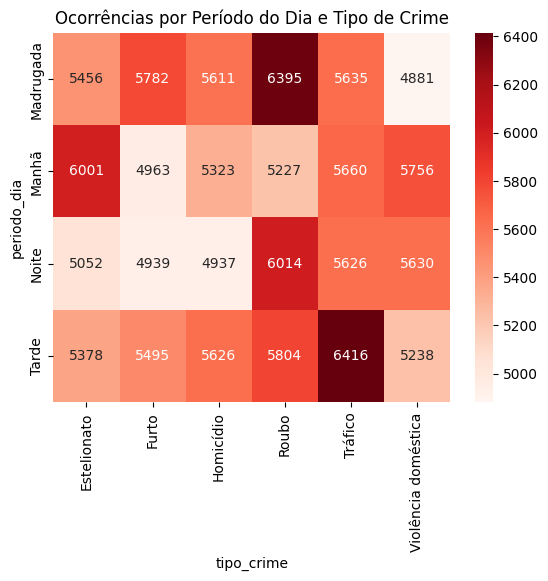

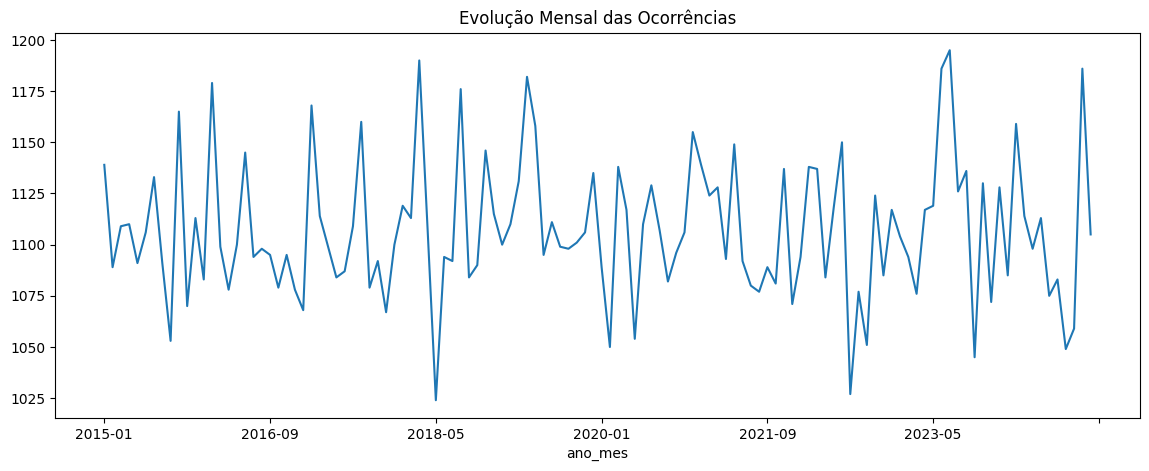

In [5]:
# Ocorrências por região
df.groupby('regiao')['ocorrencias'].sum().sort_values().plot(kind='barh')
plt.title('Total de Ocorrências por Região')
plt.show()

# Top 10 cidades
df.groupby('cidade')['ocorrencias'].sum().nlargest(10).plot(kind='bar')
plt.title('Top 10 Cidades com Mais Ocorrências')
plt.show()

# Tipo de crime
sns.countplot(data=df, y='tipo_crime', order=df['tipo_crime'].value_counts().index)
plt.title('Distribuição por Tipo de Crime')
plt.show()

# Heatmap: período do dia x tipo de crime
pivot = df.pivot_table(values='ocorrencias', index='periodo_dia',
                       columns='tipo_crime', aggfunc='sum')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds')
plt.title('Ocorrências por Período do Dia e Tipo de Crime')
plt.show()

# Evolução temporal
df.groupby('ano_mes')['ocorrencias'].sum().plot(figsize=(14,5))
plt.title('Evolução Mensal das Ocorrências')
plt.show()

**KPIs**

In [6]:
total_ocorrencias = df['ocorrencias'].sum()
total_vitimas = df['vitimas'].sum()
total_prisoes = df['prisoes'].sum()
taxa_prisao = total_prisoes / total_ocorrencias
indice_medio = df['indice_violencia'].mean()
cidade_mais_violenta = df.groupby('cidade')['ocorrencias'].sum().idxmax()
crime_mais_comum = df.groupby('tipo_crime')['ocorrencias'].sum().idxmax()

print(f"Total de Ocorrências: {total_ocorrencias:,}")
print(f"Total de Vítimas: {total_vitimas:,}")
print(f"Total de Prisões: {total_prisoes:,}")
print(f"Taxa de Prisão: {taxa_prisao:.2%}")
print(f"Índice Médio de Violência: {indice_medio:.2f}")
print(f"Cidade Mais Violenta: {cidade_mais_violenta}")
print(f"Crime Mais Comum: {crime_mais_comum}")

Total de Ocorrências: 132,845
Total de Vítimas: 22,220
Total de Prisões: 13,219
Taxa de Prisão: 9.95%
Índice Médio de Violência: 64.67
Cidade Mais Violenta: Florianópolis
Crime Mais Comum: Roubo


**Interpretação dos Resultados**

A região Sudeste concentra o maior volume de ocorrências, reflexo do maior número de cidades monitoradas.

Furto e Roubo são os crimes mais frequentes.

O período Noturno e Madrugada apresentam maior incidência de crimes violentos.

Cidades com renda média mais baixa tendem a apresentar níveis de risco mais elevados.

A taxa de prisão varia significativamente entre regiões, indicando desigualdade na eficácia policial.

**Conclusão**

O projeto demonstrou que a criminalidade não é uniforme: varia por região, tipo de crime, período do dia e condições socioeconômicas. Os KPIs e visualizações permitem priorizar ações de segurança pública em cidades e horários críticos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')